In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#Завантаження данних
orders = pd.read_csv('brazil/olist_orders_dataset.csv')
items = pd.read_csv('brazil/olist_order_items_dataset.csv')
products = pd.read_csv('brazil/olist_products_dataset.csv')


In [2]:
# Огляд данних
print("ORDERS")
print(orders.shape)
print(orders.isnull().sum())
print("\nITEMS")
print(items.shape)
print(items.isnull().sum())

ORDERS
(99441, 8)
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

ITEMS
(112650, 7)
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64


In [3]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at', 
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

# Зміюю тип данних на datetime
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

orders_delivered = orders[orders.order_status == 'delivered'].copy()
print(f'Всього замовлень:{len(orders)}')
print(f'Доставлених:{len(orders_delivered)}')
print(f'Відсоток доставлених:{len(orders_delivered) / len(orders) *100:.1f}')

orders_delivered['delivery_days'] = (
    orders_delivered['order_delivered_customer_date'] - 
    orders_delivered['order_purchase_timestamp']
).dt.days

print(f'Середній час доставки:{orders_delivered['delivery_days'].mean():.1f}днів')
print(f'Медіана доставки:{orders_delivered['delivery_days'].median():.1f}днів')

Всього замовлень:99441
Доставлених:96478
Відсоток доставлених:97.0
Середній час доставки:12.1днів
Медіана доставки:10.0днів


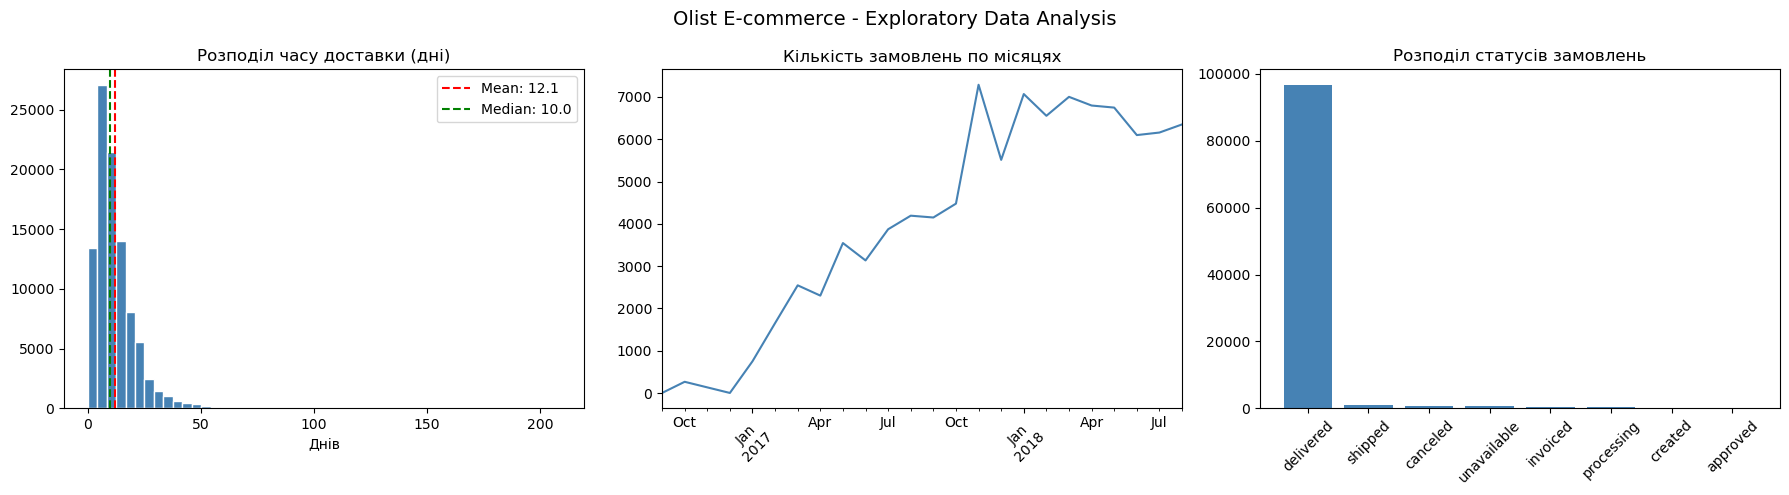

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Olist E-commerce - Exploratory Data Analysis', fontsize=14)

# Графік 1: Розподіл часу доставки
axes[0].hist(
    orders_delivered['delivery_days'].dropna(),
    bins=50, color='steelblue', edgecolor='white'
)
axes[0].axvline(
    orders_delivered['delivery_days'].mean(),
    color='red', linestyle='--', label=f"Mean: {orders_delivered['delivery_days'].mean():.1f}"
)
axes[0].axvline(
    orders_delivered['delivery_days'].median(),
    color='green', linestyle='--', label=f"Median: {orders_delivered['delivery_days'].median():.1f}"
)
axes[0].set_title('Розподіл часу доставки (дні)')
axes[0].set_xlabel('Днів')
axes[0].legend()

# Графік 2: Замовлення по місяцях
orders_delivered['month'] = orders_delivered[
    'order_purchase_timestamp'
].dt.to_period('M')
monthly = orders_delivered.groupby('month').size()
monthly.plot(ax=axes[1], color='steelblue')
axes[1].set_title('Кількість замовлень по місяцях')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)

# Графік 3: Статуси замовлень
status_counts = orders['order_status'].value_counts()
axes[2].bar(status_counts.index, status_counts.values, color='steelblue')
axes[2].set_title('Розподіл статусів замовлень')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Ключові висновки
**Медіана доставки (10 днів) менша за середню (12.1 днів)** - через аномальні затримки в окремих штатах

In [6]:
products = pd.read_csv('brazil/olist_products_dataset.csv')
categories = pd.read_csv('brazil/product_category_name_translation.csv')

In [8]:
products = products.merge(categories, on='product_category_name', how='left')

In [15]:
# Перезавантажуємо чисто
products = pd.read_csv('brazil/olist_products_dataset.csv')
categories = pd.read_csv('brazil/product_category_name_translation.csv')

# Тепер merge
products = products.merge(categories, on='product_category_name', how='left')

# Перевіряємо
print(products.columns.tolist())

['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english']


In [17]:
# Об'єднуємо всі три таблиці
df = orders_delivered.merge(items, on='order_id', how='left')
df = df.merge(
    products[['product_id', 'product_category_name_english']], 
    on='product_id', 
    how='left'
)

print(f"Розмір фінальної таблиці: {df.shape}")
print(f"Пропуски в категоріях: {df['product_category_name_english'].isnull().sum()}")
df.head(3)

Розмір фінальної таблиці: (110197, 17)
Пропуски в категоріях: 1559


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,month,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,2017-10,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,2018-07,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,2018-08,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,auto


In [20]:
# Завантажуємо customers
customers = pd.read_csv('brazil/olist_customers_dataset.csv')
print(customers.columns.tolist())

# Додаємо до нашої таблиці
df = df.merge(
    customers[['customer_id', 'customer_state']], 
    on='customer_id', 
    how='left'
)

print(f"Перевірка: {df.shape}")
print(f"customer_state пропуски: {df['customer_state'].isnull().sum()}")

['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']
Перевірка: (110197, 18)
customer_state пропуски: 0


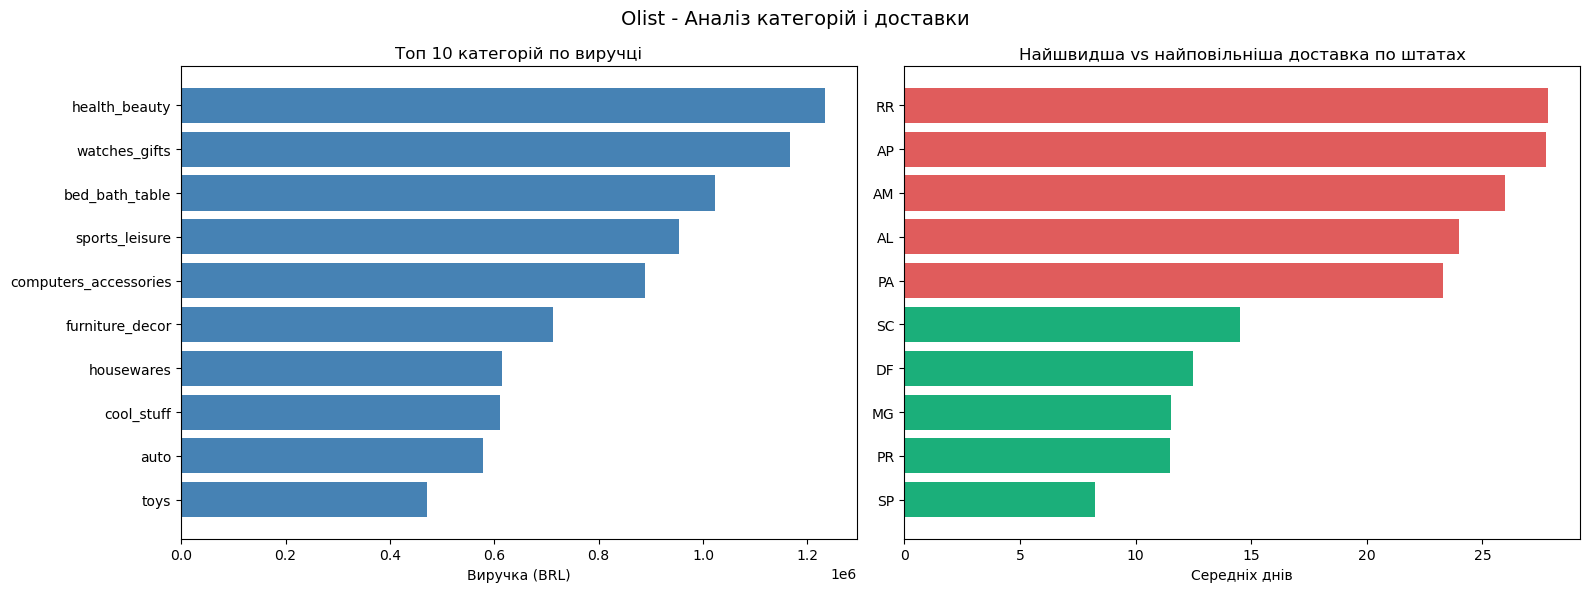

In [23]:
# Топ 10 категорій по виручці
revenue_by_category = (
    df.groupby('product_category_name_english')['price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Графік
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Olist - Аналіз категорій і доставки', fontsize=14)

# Топ категорії
axes[0].barh(
    revenue_by_category.index[::-1],
    revenue_by_category.values[::-1],
    color='steelblue'
)
axes[0].set_title('Топ 10 категорій по виручці')
axes[0].set_xlabel('Виручка (BRL)')

# Час доставки по топ-5 і bottom-5 штатах
delivery_by_state = (
    df.groupby('customer_state')['delivery_days']
    .mean()
    .sort_values()
)

top5 = delivery_by_state.head(5)
bottom5 = delivery_by_state.tail(5)
combined = pd.concat([top5, bottom5])

colors = ['#1baf7a'] * 5 + ['#e05c5c'] * 5
axes[1].barh(combined.index, combined.values, color=colors)
axes[1].set_title('Найшвидша vs найповільніша доставка по штатах')
axes[1].set_xlabel('Середніх днів')

plt.tight_layout()
plt.show()

## Ключові висновки
- **Health & Beauty** - лідер виручки з показником 1.2M BRL
- **Штат SP** доставляє найшвидше (8 днів), 
- **RR** - найповільніше (28 днів): різниця у 3.5 рази